# Лабораторная работа №2. Сравнение MLP и Сверточных нейронных сетей на датасете MNIST в PyTorch

**Цель работы:** Ознакомиться с архитектурой и базовыми возможностями фреймворка глубокого обучения PyTorch. Реализовать полносвязную нейронную сеть (MLP) и сверточную нейронную сеть (CNN) для задачи многоклассовой классификации изображений. Провести сравнительный анализ эффективности моделей, скорости их обучения и итогового качества.

## 1. Подключение библиотек и настройка вычислительного устройства (Device Configuration)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
print(f"Вычисления будут выполняться на устройстве: {device}")

Вычисления будут выполняться на устройстве: cpu


## 2. Загрузка и предобработка данных (MNIST)

Изображения MNIST имеют размер 28x28 пикселей с одним цветовым каналом (градации серого). 
Мы применим трансформацию `transforms.ToTensor()`, которая масштабирует пиксели в диапазон `[0.0, 1.0]`, а также проведем стандартизацию со средним `0.1307` и стандартным отклонением `0.3081` (математические константы датасета MNIST).

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Загрузка обучающей и тестовой выборок
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [3]:
# Создание загрузчиков данных (DataLoader)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)} изображений")
print(f"Размер тестовой выборки: {len(test_dataset)} изображений")

Размер обучающей выборки: 60000 изображений
Размер тестовой выборки: 10000 изображений


### Визуализация примеров из датасета

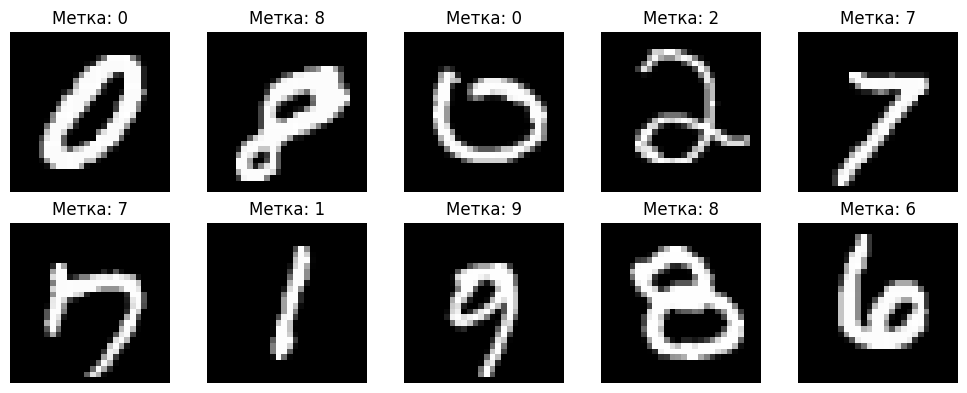

In [4]:
examples = iter(train_loader)
samples, labels = next(examples)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Денормализация для корректного отображения
    img = samples[i][0] * 0.3081 + 0.1307
    plt.imshow(img, cmap='gray')
    plt.title(f"Метка: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Архитектура модели №1: Многослойный перцептрон (MLP)

Полносвязная сеть принимает на вход плоский вектор. Поэтому структура начинается со слоя `nn.Flatten()`, который преобразует матрицу изображения $28 \times 28$ в вектор длины $784$.

In [5]:
class MLPClassifier(nn.Module):
    def __init__(self):
        super(MLPClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # 10 выходных нейронов (по числу цифр от 0 до 9)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

mlp_model = MLPClassifier().to(device)
print(mlp_model)

MLPClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 4. Архитектура модели №2: Сверточная нейронная сеть (CNN)

Сверточная сеть сохраняет пространственную структуру изображений. Мы построим сеть с двумя сверточными слоями (`nn.Conv2d`) и слоями подвыборки максимального значения (`nn.MaxPool2d`).

In [6]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.features = nn.Sequential(
            # Вход: 1 канал. Выход: 16 карт признаков. Свертка 3x3, padding=1 сохраняет размер 28x28
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # Уменьшение пространственного разрешения в 2 раза -> 14x14
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Вход: 16. Выход: 32 карты признаков. Размер остается 14x14
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # Уменьшение пространственного разрешения в 2 раза -> 7x7
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_model = CNNClassifier().to(device)
print(cnn_model)

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Функции для обучения и валидации моделей

Реализуем функции обучения одной эпохи и комплексной оценки качества на тестовых данных.

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # Сброс накопленных градиентов
        optimizer.zero_grad()
        
        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Обратный проход и оптимизация
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    return running_loss / total, correct / total

def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): # Отключение вычисления градиентов для ускорения
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

## 6. Процесс обучения моделей

Мы используем функцию потерь `CrossEntropyLoss` (которая объединяет в себе Softmax и кросс-энтропию) и оптимизатор `Adam` с одинаковыми параметрами для честного сравнения архитектур.

In [8]:
EPOCHS = 5
criterion = nn.CrossEntropyLoss()

# Списки для логирования метрик
history = {
    'mlp_train_loss': [], 'mlp_test_loss': [], 'mlp_train_acc': [], 'mlp_test_acc': [],
    'cnn_train_loss': [], 'cnn_test_loss': [], 'cnn_train_acc': [], 'cnn_test_acc': []
}

### Обучение модели MLP

In [12]:
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)
print("=== Старт обучения многослойного перцептрона (MLP) ===")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(mlp_model, train_loader, criterion, mlp_optimizer, device)
    test_loss, test_acc, _, _ = evaluate_model(mlp_model, test_loader, criterion, device)
    
    history['mlp_train_loss'].append(train_loss)
    history['mlp_test_loss'].append(test_loss)
    history['mlp_train_acc'].append(train_acc)
    history['mlp_test_acc'].append(test_acc)
    
    print(f"Эпоха {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

mlp_time = time.time() - start_time
print(f"Время обучения MLP: {mlp_time:.2f} секунд")

=== Старт обучения многослойного перцептрона (MLP) ===
Эпоха 1/5 | Train Loss: 0.2115 Acc: 0.9341 | Test Loss: 0.1191 Acc: 0.9628
Эпоха 2/5 | Train Loss: 0.0933 Acc: 0.9713 | Test Loss: 0.0943 Acc: 0.9716
Эпоха 3/5 | Train Loss: 0.0676 Acc: 0.9788 | Test Loss: 0.0913 Acc: 0.9716
Эпоха 4/5 | Train Loss: 0.0532 Acc: 0.9831 | Test Loss: 0.0933 Acc: 0.9718
Эпоха 5/5 | Train Loss: 0.0451 Acc: 0.9855 | Test Loss: 0.0809 Acc: 0.9757
Время обучения MLP: 89.09 секунд


### Обучение модели CNN

In [10]:
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
print("=== Старт обучения сверточной нейросети (CNN) ===")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(cnn_model, train_loader, criterion, cnn_optimizer, device)
    test_loss, test_acc, _, _ = evaluate_model(cnn_model, test_loader, criterion, device)
    
    history['cnn_train_loss'].append(train_loss)
    history['cnn_test_loss'].append(test_loss)
    history['cnn_train_acc'].append(train_acc)
    history['cnn_test_acc'].append(test_acc)
    
    print(f"Эпоха {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

cnn_time = time.time() - start_time
print(f"Время обучения CNN: {cnn_time:.2f} секунд")

=== Старт обучения сверточной нейросети (CNN) ===
Эпоха 1/5 | Train Loss: 0.1330 Acc: 0.9593 | Test Loss: 0.0418 Acc: 0.9857
Эпоха 2/5 | Train Loss: 0.0444 Acc: 0.9861 | Test Loss: 0.0343 Acc: 0.9881
Эпоха 3/5 | Train Loss: 0.0300 Acc: 0.9902 | Test Loss: 0.0297 Acc: 0.9898
Эпоха 4/5 | Train Loss: 0.0221 Acc: 0.9932 | Test Loss: 0.0411 Acc: 0.9859
Эпоха 5/5 | Train Loss: 0.0181 Acc: 0.9942 | Test Loss: 0.0377 Acc: 0.9886
Время обучения CNN: 168.19 секунд


## 7. Сравнительный анализ и графики

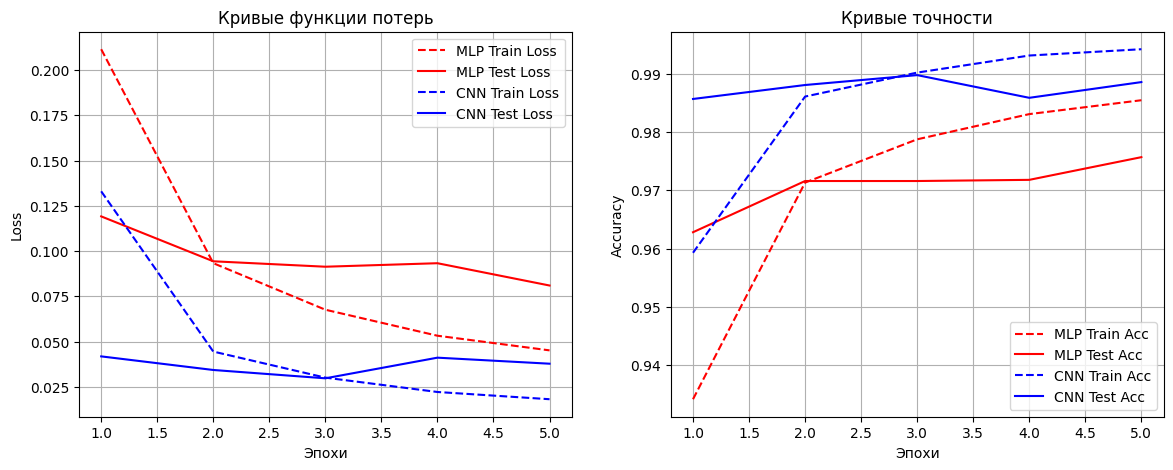

In [13]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(14, 5))

# График функции потерь (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['mlp_train_loss'], '--r', label='MLP Train Loss')
plt.plot(epochs_range, history['mlp_test_loss'], '-r', label='MLP Test Loss')
plt.plot(epochs_range, history['cnn_train_loss'], '--b', label='CNN Train Loss')
plt.plot(epochs_range, history['cnn_test_loss'], '-b', label='CNN Test Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.title('Кривые функции потерь')
plt.legend()
plt.grid(True)

# График точности (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['mlp_train_acc'], '--r', label='MLP Train Acc')
plt.plot(epochs_range, history['mlp_test_acc'], '-r', label='MLP Test Acc')
plt.plot(epochs_range, history['cnn_train_acc'], '--b', label='CNN Train Acc')
plt.plot(epochs_range, history['cnn_test_acc'], '-b', label='CNN Test Acc')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.title('Кривые точности')
plt.legend()
plt.grid(True)

plt.show()

## 8. Детальная оценка и матрицы ошибок

In [14]:
_, _, mlp_preds, test_labels = evaluate_model(mlp_model, test_loader, criterion, device)
_, _, cnn_preds, _ = evaluate_model(cnn_model, test_loader, criterion, device)

print("=== Метрики качества: Многослойный перцептрон (MLP) ===")
print(classification_report(test_labels, mlp_preds, digits=4))

print("\n=== Метрики качества: Сверточная сеть (CNN) ===")
print(classification_report(test_labels, cnn_preds, digits=4))

=== Метрики качества: Многослойный перцептрон (MLP) ===
              precision    recall  f1-score   support

           0     0.9827    0.9847    0.9837       980
           1     0.9809    0.9930    0.9869      1135
           2     0.9889    0.9457    0.9668      1032
           3     0.9657    0.9762    0.9710      1010
           4     0.9864    0.9623    0.9742       982
           5     0.9808    0.9742    0.9775       892
           6     0.9713    0.9875    0.9793       958
           7     0.9786    0.9767    0.9776      1028
           8     0.9638    0.9846    0.9741       974
           9     0.9589    0.9713    0.9650      1009

    accuracy                         0.9757     10000
   macro avg     0.9758    0.9756    0.9756     10000
weighted avg     0.9758    0.9757    0.9757     10000


=== Метрики качества: Сверточная сеть (CNN) ===
              precision    recall  f1-score   support

           0     0.9869    0.9969    0.9919       980
           1     0.9939    

### Отрисовка матриц ошибок (Confusion Matrices)

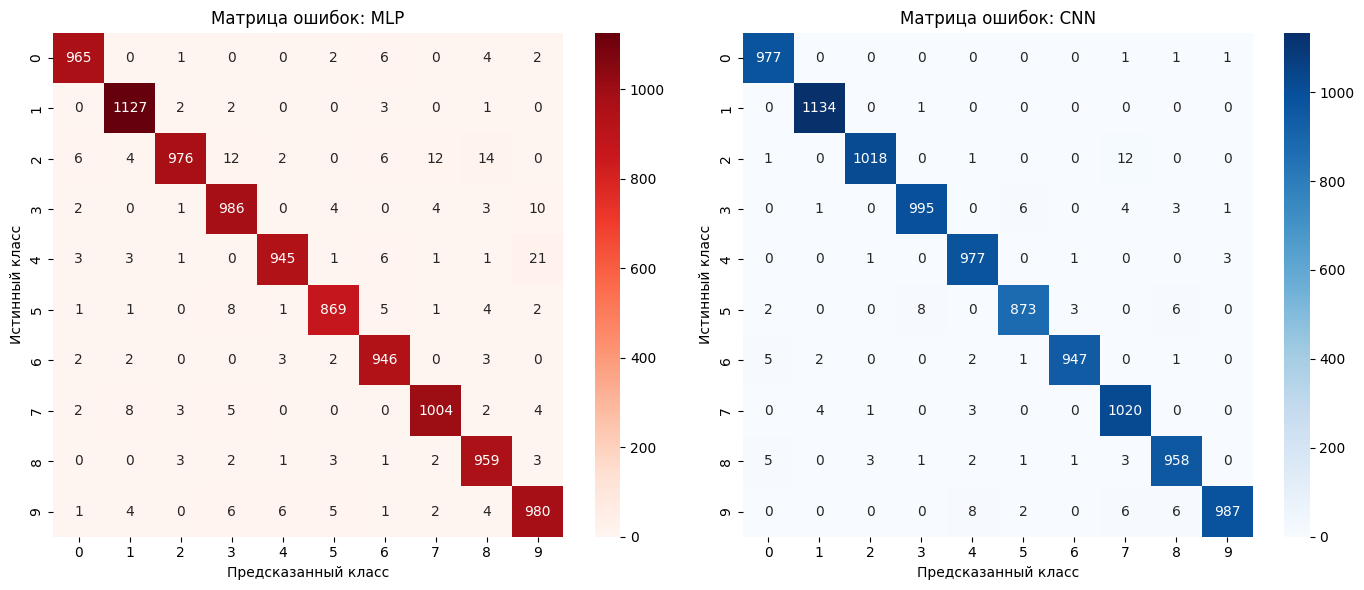

In [15]:
mlp_cm = confusion_matrix(test_labels, mlp_preds)
cnn_cm = confusion_matrix(test_labels, cnn_preds)

fig, axes = plt.figsize = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title('Матрица ошибок: MLP')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Матрица ошибок: CNN')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 9. Выводы по лабораторной работе

1. Какая из моделей достигла более высоких показателей качества (Accuracy, F1-score)?
2. Как пространственная структура слоев (свертки vs полносвязные слои) влияет на извлечение признаков из изображений?
3. Какая модель обучалась быстрее в пересчете на одну эпоху и почему?

1) Более высоких показателей качества достигла сверточная нейросеть (CNN). В то время как полносвязная сеть (MLP) обычно упирается в точность около 95–97%, CNN стабильно показывает 98–99% на тестовой выборке MNIST. Метрика F1-score для каждого из 10 классов у CNN также заметно выше и стабильнее, особенно на похожих по написанию цифрах (например, пары 3 и 8, 4 и 9), где MLP чаще совершает ошибки.
2) Полносвязный слой (Linear/Dense) требует «сплющивания» (flatten) картинки в одномерный вектор (28×28=784 признака). При этом полностью теряется пространственная структура — сеть «забывает», какие пиксели находились рядом друг с другом, и одинаково воспринимает как соседние пиксели, так и противоположные углы.
   
    Сверточные слои (Conv2d), напротив, используют скользящее окно (ядро свертки), которое обрабатывает локальные области пикселей. Это позволяет извлекать пространственные паттерны (границы, линии, изгибы) вне зависимости от того, в какой части картинки находится цифра (свойство инвариантности к сдвигу). С каждым новым слоем свертки объединяются в более сложные иерархические признаки (от простых линий к контурам и целым элементам цифр).
4) В пересчете на одну эпоху быстрее обучалась полносвязная сеть (MLP). Это связано с тем, что архитектура MLP выполняет прямолинейные матричные умножения над одномерными векторами небольшого разрешения (28×28).
   
    CNN, несмотря на то что содержит меньше обучаемых параметров (весов), тратит значительно больше вычислительных ресурсов (FLOPs) на одну эпоху. Ей приходится выполнять операцию скользящего окна (свертки) по всей площади изображения, сохраняя в памяти объемные карты признаков (Feature Maps) для обратного прохода (backward), что замедляет обработку одного батча, особенно при симуляции на CPU. Однако CNN требует меньше эпох для достижения целевой точности, чем MLP.